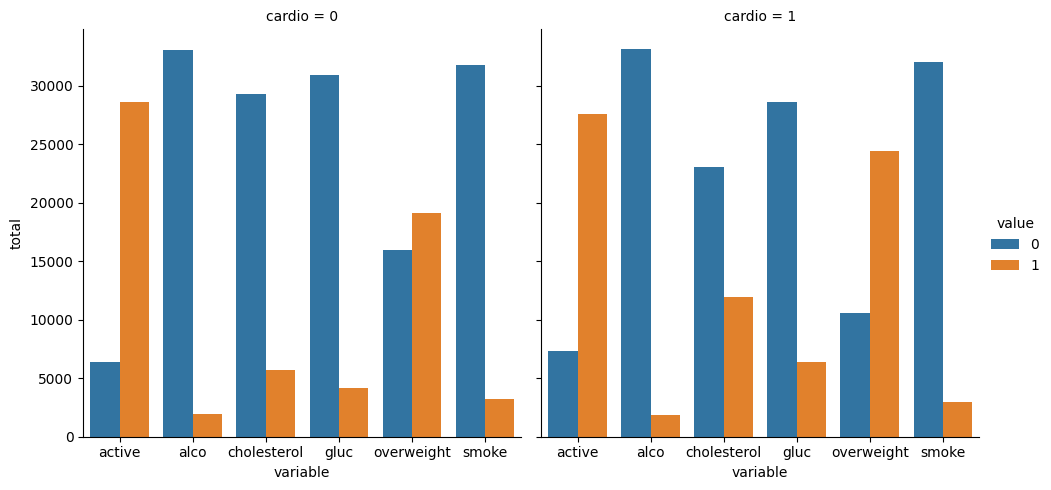

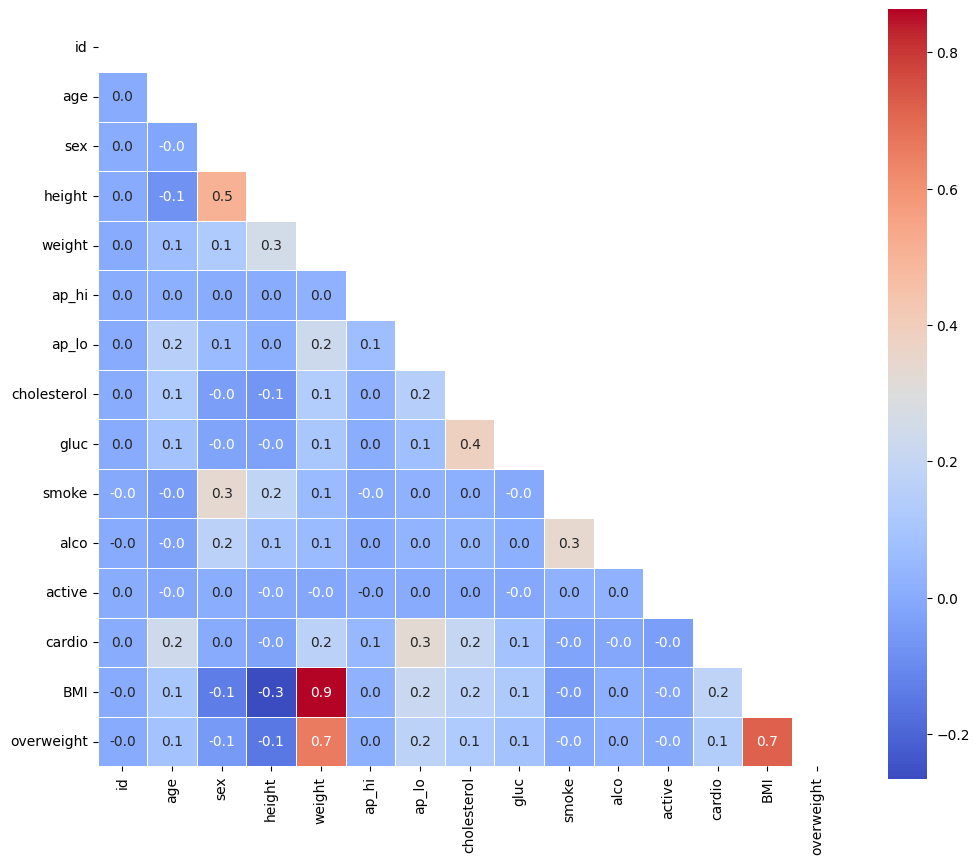

In [1]:
# Medical Data Visualizer - Working Colab Version
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load CSV directly from GitHub (no upload needed)
url = 'https://raw.githubusercontent.com/freeCodeCamp/boilerplate-medical-data-visualizer/main/medical_examination.csv'
df = pd.read_csv(url)

# Clean column names (remove extra spaces if any)
df.columns = df.columns.str.strip()

# Step 2: Add overweight column using BMI
df['BMI'] = df['weight'] / ((df['height']/100)**2)
df['overweight'] = (df['BMI'] > 25).astype(int)

# Step 3: Normalize cholesterol and glucose (0=good, 1=bad)
df['cholesterol'] = df['cholesterol'].apply(lambda x: 0 if x==1 else 1)
df['gluc'] = df['gluc'].apply(lambda x: 0 if x==1 else 1)

# Step 4: Draw Categorical Plot
def draw_cat_plot():
    df_cat = pd.melt(df,
                     id_vars=['cardio'],
                     value_vars=['cholesterol','gluc','smoke','alco','active','overweight'])
    df_cat = df_cat.groupby(['cardio','variable','value']).size().reset_index(name='total')
    fig = sns.catplot(x='variable', y='total', hue='value', col='cardio',
                      data=df_cat, kind='bar').fig
    return fig

# Step 5: Draw Heat Map
def draw_heat_map():
    # Clean data
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]

    corr = df_heat.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(12,10))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".1f", cmap='coolwarm', square=True, linewidths=.5)
    return fig

# Step 6: Run plots
fig1 = draw_cat_plot()
plt.show()

fig2 = draw_heat_map()
plt.show()

In [ ]:
print("✅ FreeCodeCamp Medical Data Visualizer Project Ready for Submission ✅")

✅ FreeCodeCamp Medical Data Visualizer Project Ready for Submission ✅
